# MOT Magnetic Field Validation

This notebook validates the anti-Helmholtz magnetic field used for a conventional MOT. It is intentionally isolated under `notebooks/mot/` and uses the dedicated `pmot.mot` subpackage so the pMOT optical-only workflow remains separate.

In [1]:
%matplotlib widget

from pathlib import Path
import sys

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == 'mot' else (Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve())
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from pmot.mot import (
    AntiHelmholtzCoilConfig,
    anti_helmholtz_axial_gradient_t_per_m,
    current_for_target_axial_gradient_a,
    default_anti_helmholtz_config,
    line_sample,
    mot_project_paths,
    plane_sample,
    plot_field_heatmap,
    plot_field_lineout,
    plot_plane_quiver,
    plot_vector_cloud_3d,
    vector_cloud_sample,
)


In [2]:
PATHS = mot_project_paths(PROJECT_ROOT)
DEFAULT_CONFIG = default_anti_helmholtz_config()
DEFAULT_GRADIENT_G_PER_CM = 100.0 * anti_helmholtz_axial_gradient_t_per_m(
    radius_m=DEFAULT_CONFIG.radius_m,
    turns_per_coil=DEFAULT_CONFIG.turns_per_coil,
    current_a=DEFAULT_CONFIG.current_a,
)

pd.Series({
    'coil_radius_mm': 1e3 * DEFAULT_CONFIG.radius_m,
    'coil_separation_mm': 1e3 * DEFAULT_CONFIG.center_separation_m,
    'turns_per_coil': DEFAULT_CONFIG.turns_per_coil,
    'current_a': DEFAULT_CONFIG.current_a,
    'axial_gradient_g_per_cm': DEFAULT_GRADIENT_G_PER_CM,
})


coil_radius_mm             40.000000
coil_separation_mm         40.000000
turns_per_coil             50.000000
current_a                   2.965677
axial_gradient_g_per_cm    10.000000
dtype: float64

## Default Coil Geometry And Field Maps

The default radius and current are chosen so the anti-Helmholtz pair produces about `10 G/cm` along the axial direction at the MOT center. The line scans and slices below use that default configuration.

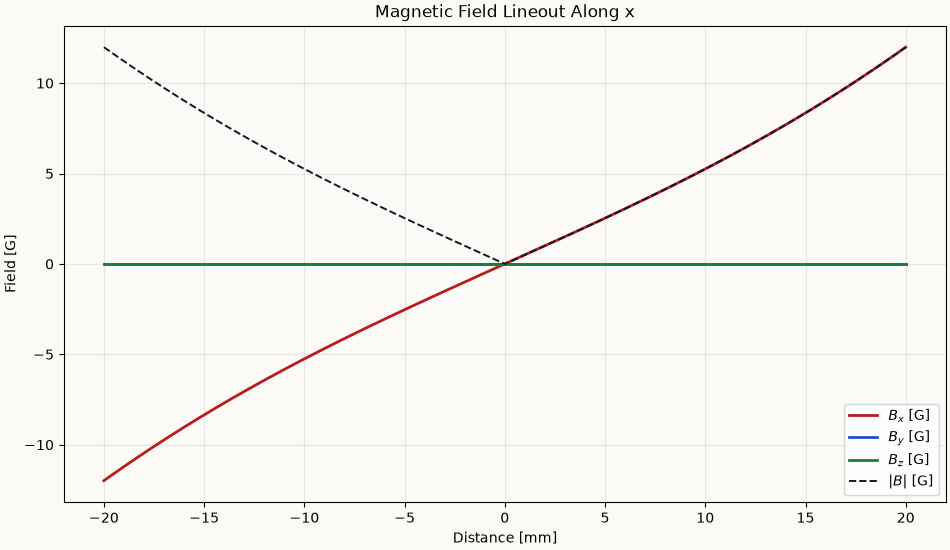

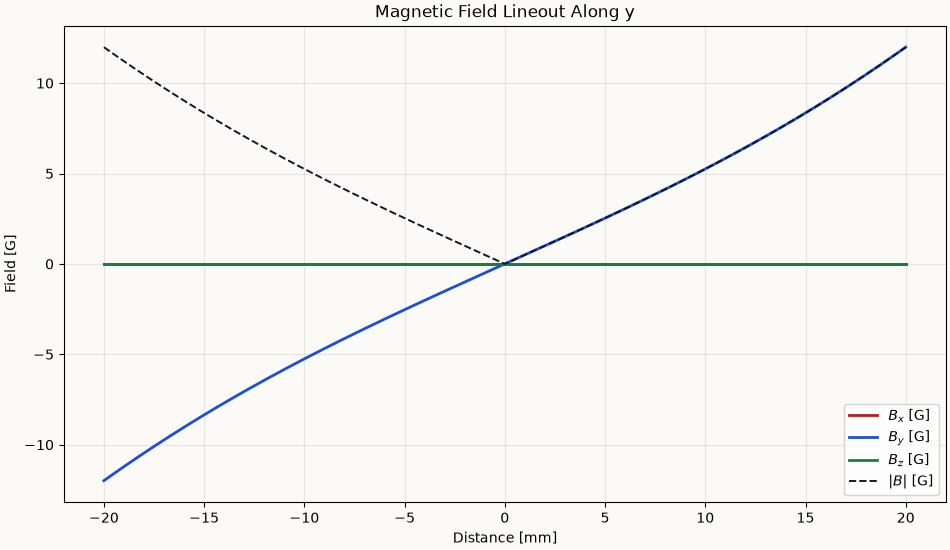

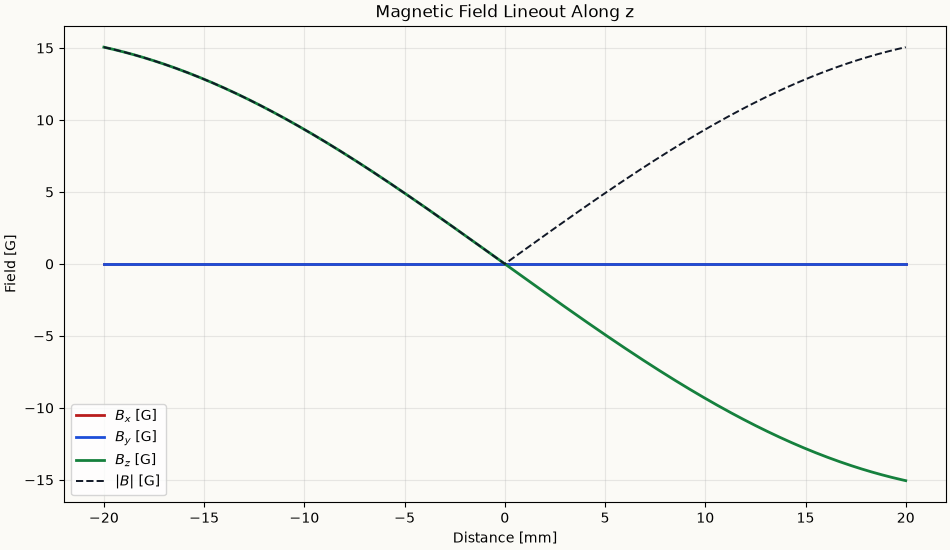

In [3]:
X_LINE = line_sample((-20e-3, 0.0, 0.0), (20e-3, 0.0, 0.0), DEFAULT_CONFIG)
Y_LINE = line_sample((0.0, -20e-3, 0.0), (0.0, 20e-3, 0.0), DEFAULT_CONFIG)
Z_LINE = line_sample((0.0, 0.0, -20e-3), (0.0, 0.0, 20e-3), DEFAULT_CONFIG)

plot_field_lineout(
    X_LINE['distance_mm'],
    {'bx_g': X_LINE['bx_g'], 'by_g': X_LINE['by_g'], 'bz_g': X_LINE['bz_g'], 'bmag_g': X_LINE['bmag_g']},
    title='Magnetic Field Lineout Along x',
    path=PATHS['outputs_fields_mot'] / 'lineout_x_default.png',
);
plot_field_lineout(
    Y_LINE['distance_mm'],
    {'bx_g': Y_LINE['bx_g'], 'by_g': Y_LINE['by_g'], 'bz_g': Y_LINE['bz_g'], 'bmag_g': Y_LINE['bmag_g']},
    title='Magnetic Field Lineout Along y',
    path=PATHS['outputs_fields_mot'] / 'lineout_y_default.png',
);
plot_field_lineout(
    Z_LINE['distance_mm'],
    {'bx_g': Z_LINE['bx_g'], 'by_g': Z_LINE['by_g'], 'bz_g': Z_LINE['bz_g'], 'bmag_g': Z_LINE['bmag_g']},
    title='Magnetic Field Lineout Along z',
    path=PATHS['outputs_fields_mot'] / 'lineout_z_default.png',
);


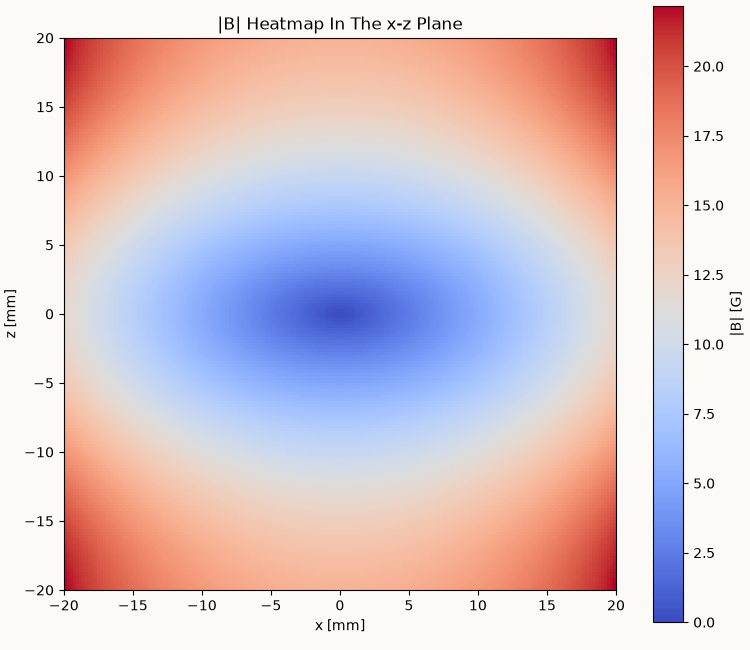

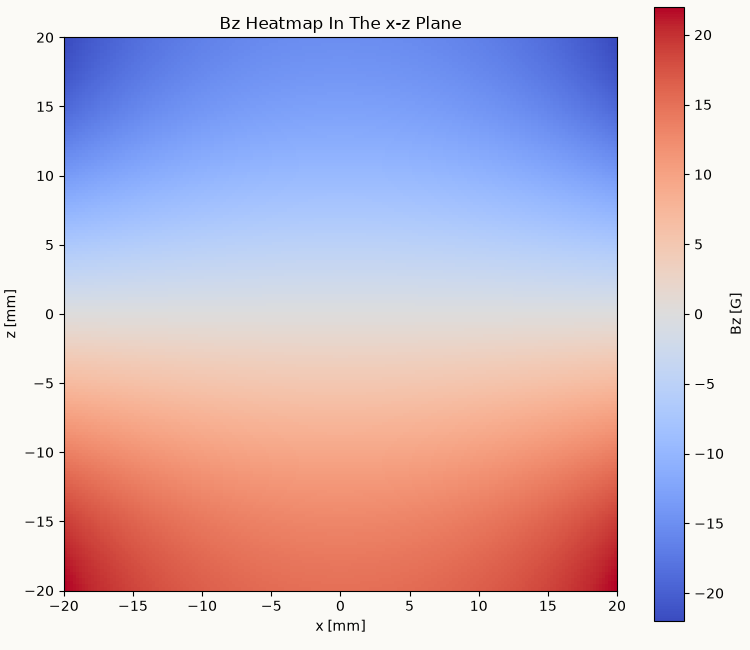

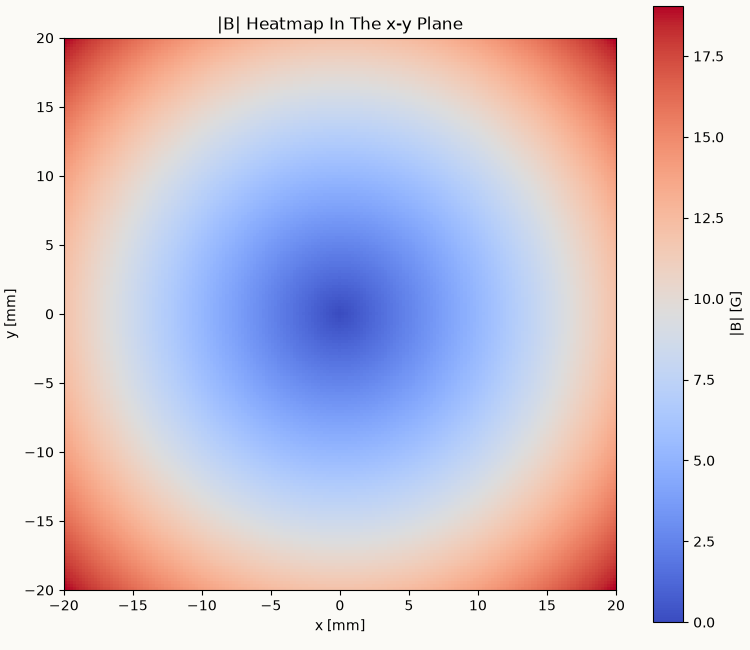

In [4]:
XZ_PLANE = plane_sample('xz', extent_m=20e-3, config=DEFAULT_CONFIG, samples_per_axis=181)
XY_PLANE = plane_sample('xy', extent_m=20e-3, config=DEFAULT_CONFIG, samples_per_axis=181)

plot_field_heatmap(
    XZ_PLANE['axis_values_m'],
    XZ_PLANE['bmag_g'],
    plane='xz',
    title='|B| Heatmap In The x-z Plane',
    colorbar_label='|B| [G]',
    path=PATHS['outputs_figures_mot'] / 'heatmap_bmag_xz_default.png',
);
plot_field_heatmap(
    XZ_PLANE['axis_values_m'],
    XZ_PLANE['bz_g'],
    plane='xz',
    title='Bz Heatmap In The x-z Plane',
    colorbar_label='Bz [G]',
    path=PATHS['outputs_figures_mot'] / 'heatmap_bz_xz_default.png',
);
plot_field_heatmap(
    XY_PLANE['axis_values_m'],
    XY_PLANE['bmag_g'],
    plane='xy',
    title='|B| Heatmap In The x-y Plane',
    colorbar_label='|B| [G]',
    path=PATHS['outputs_figures_mot'] / 'heatmap_bmag_xy_default.png',
);


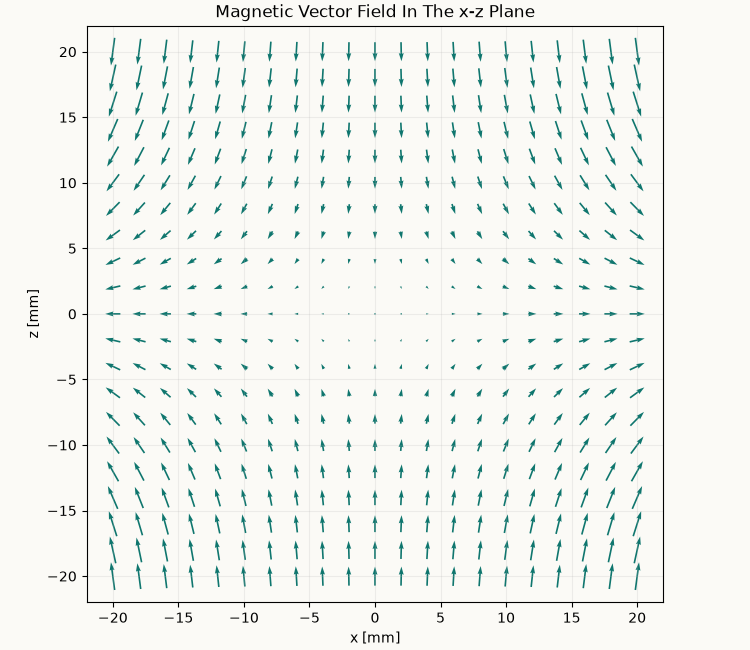

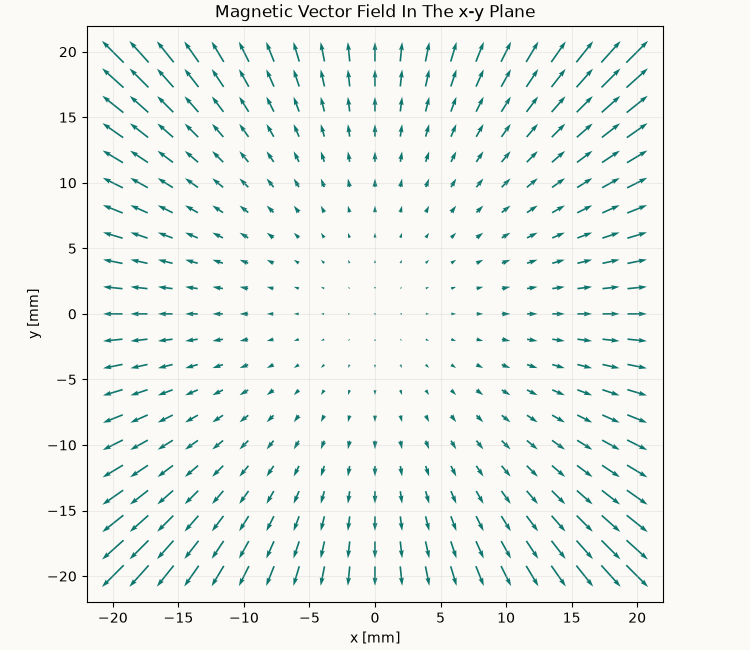

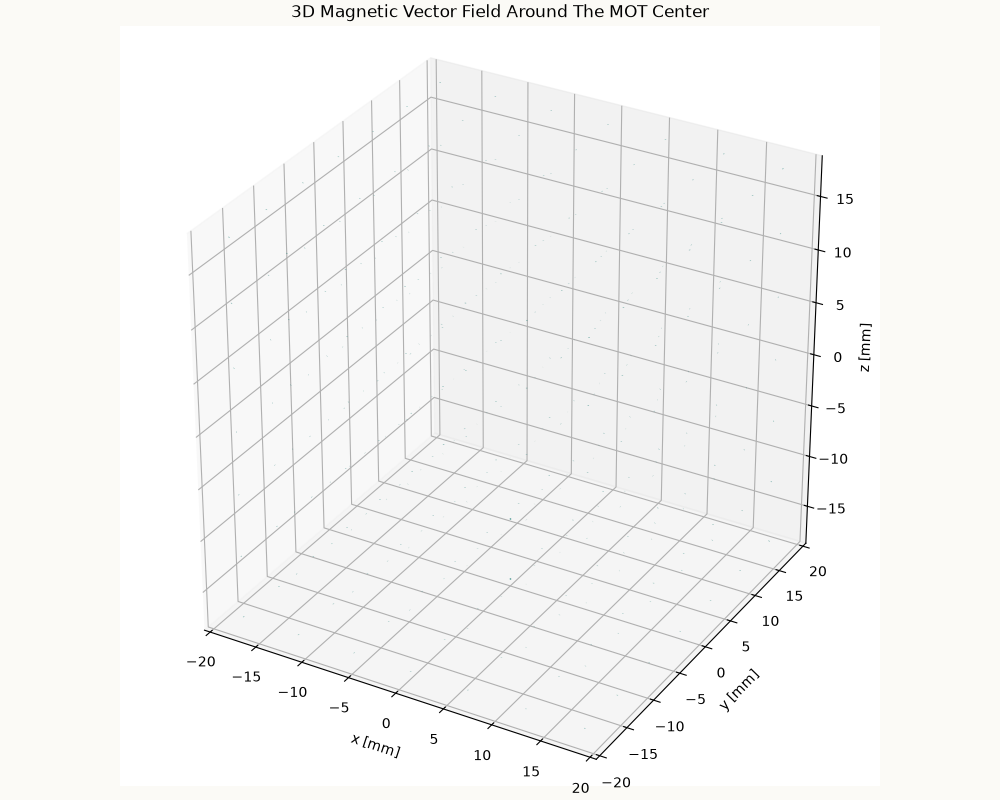

In [5]:
plot_plane_quiver(
    XZ_PLANE['axis_values_m'],
    XZ_PLANE['component_1_g'],
    XZ_PLANE['component_2_g'],
    plane='xz',
    title='Magnetic Vector Field In The x-z Plane',
    stride=9,
    path=PATHS['outputs_figures_mot'] / 'quiver_xz_default.png',
);
plot_plane_quiver(
    XY_PLANE['axis_values_m'],
    XY_PLANE['component_1_g'],
    XY_PLANE['component_2_g'],
    plane='xy',
    title='Magnetic Vector Field In The x-y Plane',
    stride=9,
    path=PATHS['outputs_figures_mot'] / 'quiver_xy_default.png',
);
VECTOR_CLOUD = vector_cloud_sample(extent_m=18e-3, config=DEFAULT_CONFIG, samples_per_axis=7)
plot_vector_cloud_3d(
    VECTOR_CLOUD,
    title='3D Magnetic Vector Field Around The MOT Center',
    path=PATHS['outputs_figures_mot'] / 'vector_cloud_3d_default.png',
);


## Interactive Coil Controls

Use the controls below to vary the coil radius and current directly. The axial gradient at the center is recomputed each time so the field response is visible immediately.

In [6]:
def draw_mot_field_maps(
    radius_mm: float = 40.0,
    current_a: float = float(DEFAULT_CONFIG.current_a),
    turns_per_coil: int = DEFAULT_CONFIG.turns_per_coil,
    extent_mm: float = 20.0,
    samples_per_axis: int = 151,
):
    config = AntiHelmholtzCoilConfig(
        radius_m=1e-3 * radius_mm,
        turns_per_coil=turns_per_coil,
        current_a=current_a,
        center_separation_m=1e-3 * radius_mm,
    )
    gradient_g_per_cm = 100.0 * anti_helmholtz_axial_gradient_t_per_m(
        radius_m=config.radius_m,
        turns_per_coil=config.turns_per_coil,
        current_a=config.current_a,
    )
    xz_plane = plane_sample('xz', extent_m=1e-3 * extent_mm, config=config, samples_per_axis=samples_per_axis)
    z_line = line_sample((0.0, 0.0, -1e-3 * extent_mm), (0.0, 0.0, 1e-3 * extent_mm), config=config)

    figure = plt.figure(figsize=(14, 10), constrained_layout=True)
    figure.patch.set_facecolor('#fbfaf6')
    grid = figure.add_gridspec(2, 2)
    line_axis = figure.add_subplot(grid[0, 0])
    heatmap_axis = figure.add_subplot(grid[0, 1])
    quiver_axis = figure.add_subplot(grid[1, 0])
    cloud_axis = figure.add_subplot(grid[1, 1], projection='3d')

    for axis in (line_axis, heatmap_axis, quiver_axis):
        axis.set_facecolor('#fbfaf6')

    line_axis.plot(z_line['distance_mm'], z_line['bx_g'], color='#b91c1c', linewidth=1.9, label='Bx')
    line_axis.plot(z_line['distance_mm'], z_line['by_g'], color='#1d4ed8', linewidth=1.9, label='By')
    line_axis.plot(z_line['distance_mm'], z_line['bz_g'], color='#15803d', linewidth=1.9, label='Bz')
    line_axis.plot(z_line['distance_mm'], z_line['bmag_g'], color='#111827', linewidth=1.4, linestyle='--', label='|B|')
    line_axis.set_title('Axial Lineout Along z')
    line_axis.set_xlabel('z [mm]')
    line_axis.set_ylabel('Field [G]')
    line_axis.grid(True, alpha=0.28)
    line_axis.legend(loc='best', frameon=True)

    extent = (
        1e3 * xz_plane['axis_values_m'][0],
        1e3 * xz_plane['axis_values_m'][-1],
        1e3 * xz_plane['axis_values_m'][0],
        1e3 * xz_plane['axis_values_m'][-1],
    )
    image = heatmap_axis.imshow(np.array(xz_plane['bmag_g']), origin='lower', extent=extent, aspect='equal', cmap='coolwarm')
    figure.colorbar(image, ax=heatmap_axis, shrink=0.8).set_label('|B| [G]')
    heatmap_axis.set_title('|B| Heatmap In x-z')
    heatmap_axis.set_xlabel('x [mm]')
    heatmap_axis.set_ylabel('z [mm]')

    coordinates_mm = 1e3 * np.array(xz_plane['axis_values_m'])
    coord_x, coord_z = np.meshgrid(coordinates_mm, coordinates_mm)
    stride = max(1, samples_per_axis // 18)
    quiver_axis.quiver(
        coord_x[::stride, ::stride],
        coord_z[::stride, ::stride],
        np.array(xz_plane['component_1_g'])[::stride, ::stride],
        np.array(xz_plane['component_2_g'])[::stride, ::stride],
        color='#0f766e',
        pivot='mid',
    )
    quiver_axis.set_title('Vector Field In x-z')
    quiver_axis.set_xlabel('x [mm]')
    quiver_axis.set_ylabel('z [mm]')
    quiver_axis.set_aspect('equal')
    quiver_axis.grid(True, alpha=0.2)

    cloud = np.array(vector_cloud_sample(extent_m=1e-3 * extent_mm, config=config, samples_per_axis=7))
    cloud_axis.quiver(
        1e3 * cloud[:, 0],
        1e3 * cloud[:, 1],
        1e3 * cloud[:, 2],
        cloud[:, 3],
        cloud[:, 4],
        cloud[:, 5],
        color='#0f766e',
        length=8.0,
    )
    cloud_axis.set_title('3D Vector Cloud')
    cloud_axis.set_xlabel('x [mm]')
    cloud_axis.set_ylabel('y [mm]')
    cloud_axis.set_zlabel('z [mm]')
    cloud_axis.set_box_aspect((1.0, 1.0, 1.0))

    summary = pd.Series({
        'coil_radius_mm': radius_mm,
        'coil_current_a': current_a,
        'turns_per_coil': turns_per_coil,
        'axial_gradient_g_per_cm': gradient_g_per_cm,
    })
    plt.show()
    display(summary)


widgets.interact(
    draw_mot_field_maps,
    radius_mm=widgets.FloatSlider(value=40.0, min=10.0, max=80.0, step=1.0, description='radius [mm]'),
    current_a=widgets.FloatSlider(value=float(DEFAULT_CONFIG.current_a), min=0.1, max=12.0, step=0.1, description='current [A]'),
    turns_per_coil=widgets.IntSlider(value=DEFAULT_CONFIG.turns_per_coil, min=1, max=200, step=1, description='turns'),
    extent_mm=widgets.FloatSlider(value=20.0, min=5.0, max=40.0, step=1.0, description='extent [mm]'),
    samples_per_axis=widgets.IntSlider(value=151, min=51, max=251, step=20, description='samples'),
);


interactive(children=(FloatSlider(value=40.0, description='radius [mm]', max=80.0, min=10.0, step=1.0), FloatS…

In [ ]:
def current_for_10_g_per_cm(radius_mm: float = 40.0, turns_per_coil: int = 50):
    current_a = current_for_target_axial_gradient_a(0.1, radius_m=1e-3 * radius_mm, turns_per_coil=turns_per_coil)
    return pd.Series({
        'radius_mm': radius_mm,
        'turns_per_coil': turns_per_coil,
        'current_a_for_10_g_per_cm': current_a,
    })

widgets.interact(
    current_for_10_g_per_cm,
    radius_mm=widgets.FloatSlider(value=40.0, min=10.0, max=80.0, step=1.0, description='radius [mm]'),
    turns_per_coil=widgets.IntSlider(value=50, min=1, max=200, step=1, description='turns'),
);


interactive(children=(FloatSlider(value=40.0, description='radius [mm]', max=80.0, min=10.0, step=1.0), IntSli…